# A place to toy around with spaceprime stuff
Notes are in my Obsidian vault. 
Note to self- I'm using the spaceprime conda environment.

## raster import with rasterio

In [188]:
import rasterio

filepath = "scratch-data/iheringii_10km.tif"

with rasterio.open(filepath) as src:
    print(src.profile)
    r = src.read(1, masked=True)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 68, 'height': 80, 'count': 1, 'crs': CRS.from_epsg(4326), 'transform': Affine(0.0833333333333334, 0.0, -50.50833333333334,
       0.0, -0.08333333333333334, -23.07500000000001), 'blockysize': 30, 'tiled': False, 'compress': 'lzw', 'interleave': 'band'}


Plot the raster with matplotlib

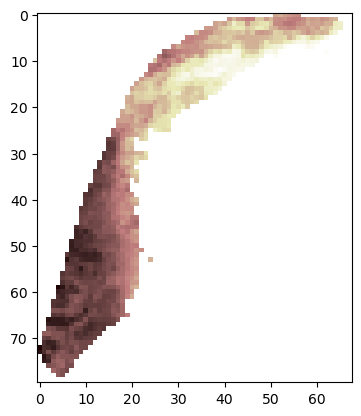

In [64]:
from matplotlib import pyplot

pyplot.imshow(r, cmap='pink')

pyplot.show() 

# Function to convert raster stack to K values

I'm writing a function to convert a single raster or multiple rasters to local carrying capacities (K) with the possibility of a linear, hinge, or sigmoid transformation

This is a basic function to transform a raster to local carrying capacity (K) values. This function was created with the idea of taking in presence probability/habitat suitability rasters scaled from 0 to 1, where 0 is no suitability and 1 is the highest suitability. However, it is flexible enough to accomodate other continuous rasters that can be coaxed to a 0 to 1 scale with the operation `(data - np.min(data)) / (np.max(data) - np.min(data))` by setting the `normalize` flag to `True`. 
- The "linear" transformation multiplies the input (raw or transformed) values by the maximum local carrying capacity (max_local_k).
- The "hinge" transformation creates a raster where values below the `threshold` value are set to zero and values about the `threshold` value are set to 1. Note, this transformation is applied *after* normalizing if the `normalize` flag is set to `True`.
- The "sigmoid" transformation applies a sigmoid function to the data using Eq. 1 from [Frazier and Wang 2013, Modeling landscape structure response across a gradient of land cover intensity](https://www.researchgate.net/publication/257319938_Modeling_landscape_structure_response_across_a_gradient_of_land_cover_intensity), where an `inflection_point` and `slope` are specified. The `inflection_point` can be thought of like a `threshold` value, where original values below this value descend quicker to zero, and values about this value increase quicker to 1. The slope determines how fast values change on either side of the inflection point. A sufficiently steep slope makes this a hinge function, while a sufficiently shallow slope makes this a linear function.

In [140]:
import numpy as np
def raster_to_k(raster, transformation = "linear", max_local_k = 100, normalize = False, threshold = None, inflection_point = 0.5, slope = 0.05):

    d = raster.filled(0)

    if normalize:
        def normalize(rast):
            return (rast - np.min(rast)) / (np.max(rast) - np.min(rast))
        
        d = normalize(d)
    
    if transformation == "linear":
        t = d * max_local_k
        t = np.ceil(t)

    if transformation == "hinge":
        t = d
        t[t < threshold] = 0
        t[t >= threshold] = max_local_k

    if transformation == "sigmoid":
        def sigmoid(x, a, b):
            y = 1.0 / (1.0 + np.ma.exp(-(x - a) / b))
            return(y)
        
        sigmoid_v = np.vectorize(sigmoid)
        t = sigmoid_v(d, inflection_point, slope) * max_local_k
        t = np.ceil(t)
    
    # convert to integer
    t = t.astype(int)

    return(t)
    
  

In [142]:
import numpy as np
ihe_t = raster_to_k(r, transformation="linear")

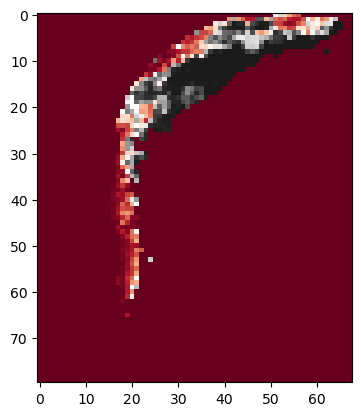

In [141]:
from matplotlib import pyplot

pyplot.imshow(ihe_t, cmap='RdGy')

pyplot.show() 

## Function to create a migration matrix from a "local K" matrix
This is a skeleton to facilitate creating a migration matrix that isn't just a single migration value. 

I started making this with the idea that someone may want to use a raster with constant local carrying capacities (K) across the landscape and have the migration rate vary based on some other variable like difference in elevation. 

Right now, this just takes the difference in K values between two neighboring cells and sets it as the bidirectional migration rate. This is obviously unrealistic, but I needed a simple function to begin to code up this function. 

In [69]:
import numpy as np
def k_to_mig_matrix(k):

    # Convert the input matrix to a 1D array
    k_flat = np.ravel(k)

    # Initialize the migration matrix
    m = np.zeros((k_flat.shape[0], k_flat.shape[0]))

    # Iterate over each cell in the input matrix and compute the migration rates
    for i in range(k_flat.shape[0]):
        for j in range(k_flat.shape[0]):
            if i != j:
                diff = abs(k_flat[i] - k_flat[j])
                if (i // 4 == j // 4) and abs(i - j) == 1:
                    # Edge neighbor
                    m[i, j] = diff
                elif (i % 4 == j % 4) and abs(i - j) == 4:
                    # Edge neighbor
                    m[i, j] = diff
                elif abs(i - j) == 3 or abs(i - j) == 12:
                    # Corner neighbor
                    m[i, j] = diff
                elif abs(i - j) == 4:
                    # Center neighbor
                    m[i, j] = diff
    return(m)

## 2D Stepping Stone model

Now to write a basic function! This will read in a single raster and create an msprime demography object with that single raster. I'm importing Jerome Kelleher's version of the 2D stepping stone model to work with. 
`initial_size` is the local population size for each deme in the model
`rate` is the migration rate between populations. Can be a single numerical value or a matrix that corresponds to all migration edges in the model.


In [70]:
import msprime
import numpy as np

def stepping_stone2d(initial_size, rate):
    assert len(initial_size.shape) <= 3

    n, m = initial_size.shape
    N = n * m
    model = msprime.Demography.isolated_model(initial_size.reshape(N))

    if np.array(rate).ndim == 0:
        M = model.migration_matrix
        for j in range(n):
            for k in range(m):
                index = j * m + k
                model.populations[index].name = f"pop_{j}_{k}"
                M[index, index - 1] = rate
                M[index, (index + 1) % N] = rate
                M[index, index - m] = rate
                M[index, (index + m) % N] = rate

                M[index - 1, index] = rate
                M[(index + 1) % N, index] = rate
                M[index - m, index] = rate
                M[(index + m) % N, index] = rate
    else:
        assert rate.shape == (N, N), f"Expected a migration matrix with the shape {(N, N)} and instead got {rate.shape}"
        model.migration_matrix = rate

    
    return model


## Add collecting phase to 2D stepping stone model

The `split_array()` function splits any 1D array into equal-sized chunks, but makes sure the chunk size is never less than 2. If the chunk is less than 2, the chunk is merged with the chunk before it. 

`ancestral_size` is the size of the ancestral population that all demes coalesce to. This is the "collecting phase" of the simulation and corresponds to the time when space no longer matters for genetic diversity. 

`collecting_time` is the time in generations that the metapopulation merges into the ancestral population(s)

In [75]:
import msprime
import numpy as np

def split_array(input_array, chunk_size=2):
    # calculate the number of chunks needed
    num_chunks = (len(input_array) + chunk_size - 1) // chunk_size

    # ensure at least two elements in the last chunk
    # this merges the last chunk with the one before it
    if len(input_array) % chunk_size == 1:
        num_chunks -= 1

    # split the array using numpy.array_split()
    return np.array_split(input_array, num_chunks)

def add_collecting_phase(model, ancestral_size, collecting_time):
    # add an ancestral population
    model.add_population(name = "ANC", initial_size=ancestral_size)

    # get names of populations for initiating the collecting phase
    pop_names = [pop.name for pop in model.populations if pop.name != "ANC"]
    
    # split the pop_names list into chunks of at least size 2 so the population_split derived populations are a list
    pop_names_split = split_array(pop_names, chunk_size=2)

    # add the time when the spatial simulation collapses into the collecting phase
    [model.add_population_split(time = collecting_time, derived = name, ancestral = "ANC") for name in pop_names_split]

    return model

## Add demographic changes based on landscape change to 2D stepping stone model

The `model` is an `msprime.Demography` object that needs to be initialized using `stepping_stone_2d()`.  
`k_stack()` is a 3D numpy array of the local carrying capacities across the landscape for each timestep except the most current timestep.  
`timestep` is the amount of time that passes between each landscape change, measured in generations. For instance, if each landscape is 100 years apart and the generation time of the organism is 1 year, `timestep` is 100. However, if the generation time of the organism is 2 years, `timestep` is 50. 



In [125]:
import msprime
import numpy as np
def add_landscape_change(model, k_stack, timestep = 1):
    # interate through each raster in the raster stack
    for step in range(k_stack.shape[0]):
        # get the k values of the raster
        kmat = k_stack[step]
        # get the shape of the raster
        n, m = kmat.shape
        # iterate through each value in the raster
        for j in range(n):
            for k in range(m):
                # add a demographic change to each cell in the raster
                model.add_population_parameters_change(time=step * timestep, population=f"pop_{j}_{k}", initial_size=kmat[j, k])
    
    return model


## Model testing

Write two rasters to a raster stack so I have a multiband raster to work with.

In [189]:
import rasterio

file_list = ["scratch-data/iheringii_10km.tif", "scratch-data/iheringii_lgm_10km.tif"]

# Read metadata of first file
with rasterio.open(file_list[0]) as src0:
    meta = src0.meta

# Update meta to reflect the number of layers
meta.update(count = len(file_list))

# Read each layer and write it to stack
with rasterio.open('scratch-data/iheringii_stack_10km.tif', 'w', **meta) as dst:
    for id, layer in enumerate(file_list, start=1):
        with rasterio.open(layer) as src1:
            dst.write_band(id, src1.read(1))


Read in the multiband raster

In [194]:
import rasterio

filepath = "scratch-data/iheringii_stack_10km.tif"

with rasterio.open(filepath) as src:
    print(src.profile)
    r = src.read(masked=True)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': 68, 'height': 80, 'count': 2, 'crs': CRS.from_epsg(4326), 'transform': Affine(0.0833333333333334, 0.0, -50.50833333333334,
       0.0, -0.08333333333333334, -23.07500000000001), 'blockysize': 15, 'tiled': False, 'interleave': 'pixel'}


In [166]:
# make sure both rasters get read it
r.shape

(2, 80, 68)

In [195]:
k = raster_to_k(r, transformation="linear", max_local_k = 1000)

k.shape

(2, 80, 68)

In [196]:
m = stepping_stone2d(k[0], rate = 0.01)

In [197]:
m = add_landscape_change(model = m, k_stack = k, timestep = 20000)

In [198]:
m = add_collecting_phase(m, ancestral_size=1e6, collecting_time=20001)

In [199]:
ts = msprime.sim_ancestry({"pop_1_41": 2, "pop_1_42": 2}, sequence_length=1e7, demography = m, recombination_rate=1e-9)

The provenance information for the resulting tree sequence is 143.86MB. This is nothing to worry about as provenance is a good thing to have, but if you want to save this memory/storage space you can disable provenance recording by setting record_provenance=False


In [200]:
ts

In [201]:
ts_first = ts.at_index(0)
print(ts_first.draw_text())

    13163      
  ┏━━━┻━━━━┓   
  ┃      6614  
  ┃     ┏━━┻━━┓
1402    ┃     ┃
┏━┻┓    ┃     ┃
┃  ┃   38     ┃
┃  ┃  ┏━┻━┓   ┃
┃  ┃  ┃  26   ┃
┃  ┃  ┃ ┏━┻┓  ┃
┃  ┃  ┃ ┃ 17  ┃
┃  ┃  ┃ ┃ ┏┻┓ ┃
┃  8  ┃ ┃ ┃ ┃ ┃
┃ ┏┻┓ ┃ ┃ ┃ ┃ ┃
0 2 4 1 3 5 7 6



In [202]:
m = msprime.sim_mutations(ts, rate = 1e-9)
m

In [186]:
import tskit

ts.diversity(mode="branch") * 1e-9

0.001333154745388316

In [187]:
m.diversity()

0.0013590357142857308